## Imports Section:

In [61]:
import numpy as np
import pandas as pd
import math
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

import seaborn as sns

In [62]:
import librosa
import warnings

In [63]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [64]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

In [65]:
import convert_between_detector_file_formats as conversion

In [66]:
from sklearn.cluster import KMeans
LABEL_FOR_GROUPS = {
                    0: 'LF', 
                    1: 'HF'
                    }

## Function and Constant Definitions

In [67]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}
FILE_SITES = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}

RAVENPRO_TABLE_EXTENSION = ".txt"
RAVENPRO_TABLE_FORMAT = "\t"
RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR = Path.home() / 'Documents/Research/mila_files/mila-human-wav-txt'
KALEIDOSCOPE_DETS_SAVE_DIR = Path.home() / 'Documents'
BD2_DETS_SAVE_DIR = Path(f'20250130__group_threshold_sweep_results')
TP_CLASSIFICATION_THRESHOLD = 0.050
OVERLAP_TIME_THRESHOLD = 0.012
SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

In [68]:
def convert_kaleidoscopedf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = df['OFFSET'] - 0.005
    bd2_df['end_time'] = df['OFFSET'] + df['DURATION'] + 0.01
    bd2_df['low_freq'] = df['Fmin'] - 2000
    bd2_df['high_freq'] = df['Fmax'] + 2000
    bd2_df['input_file'] = df['IN FILE']
    bd2_df['input_dir'] = df['INDIR']
    bd2_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        bd2_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        bd2_df['TOP1MATCH'] = df['TOP1MATCH']
    bd2_df['TOP1DIST'] = df['TOP1DIST']
    bd2_df['TOP2MATCH'] = df['TOP2MATCH']
    bd2_df['TOP2DIST'] = df['TOP2DIST']
    bd2_df['TOP3MATCH'] = df['TOP3MATCH']
    bd2_df['TOP3DIST'] = df['TOP3DIST']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def get_section_of_call_in_file(detection, audio_file):
    fs = audio_file.samplerate
    num_frames = audio_file.frames
    file_length = num_frames/fs

    call_dur = (detection['end_time'] - detection['start_time'])
    pad = min(min(detection['start_time'] - call_dur, file_length - detection['end_time']), 0.006) / 3
    start = detection['start_time'] - call_dur - (3*pad)
    duration = ((2 * call_dur) + (4*pad))

    try:
        audio_file.seek(int(fs*start))
        audio_seg = audio_file.read(int(fs*duration))
        length_of_section = call_dur + (2*pad)
    except sf.LibsndfileError as e:
        print(f'Start time : {start} invalid, detection starts at {detection["start_time"]} in segment:{audio_file.name}')
        audio_seg = None
        length_of_section = 0

    return audio_seg, length_of_section, pad

def return_true_positives_using_human_df(human_df, machine_df):
    dist_matrix = np.zeros((len(machine_df), len(human_df)))
    association_matrix = np.zeros((len(machine_df), len(human_df)), dtype='bool')
    collect_human = pd.DataFrame()
    collect_bd2 = pd.DataFrame()
    for index in range(len(machine_df)):
        batdetect2_row = machine_df.iloc[index]
        dist_to_all_calls = ((human_df['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
        dist_matrix[index,:] = dist_to_all_calls
    
        dist_to_all_calls[np.abs(dist_to_all_calls)>=TP_CLASSIFICATION_THRESHOLD] = 1
        dist_to_all_calls[np.abs(dist_to_all_calls)<TP_CLASSIFICATION_THRESHOLD] = 0
        if np.abs(dist_to_all_calls-1).sum() > 1:
            collect_human = pd.concat([collect_human, human_df[dist_to_all_calls<0.5]])
            collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

        association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

    human_bd2_true_positives = human_df.loc[np.logical_or.reduce(association_matrix, axis=0)]
    machine_false_negatives = human_df.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
    machine_true_positives = machine_df.loc[np.logical_or.reduce(association_matrix, axis=1)]
    machine_false_positives = machine_df.loc[~(np.logical_or.reduce(association_matrix, axis=1))]

    separated_performance_dfs = dict()
    separated_performance_dfs['machine_true_positives'] = machine_true_positives
    separated_performance_dfs['machine_false_positives'] = machine_false_positives
    separated_performance_dfs['machine_false_negatives'] = machine_false_negatives
    separated_performance_dfs['human_true_positives'] = human_bd2_true_positives

    return association_matrix, separated_performance_dfs

In [69]:
file_keys = list(FILE_SITES.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

## Following the confusion matrix structure shown below

![image](example_confusion_matrix.png)

In [70]:
welch_key = 'all_locations'
output_dir = Path(f'{Path().home()}/duty-cycle-investigation/data/generated_welch/{welch_key}')
output_file_type = 'top1_inbouts_welch_signals'
welch_data = pd.read_csv(output_dir / f'2022_{welch_key}_{output_file_type}.csv', index_col=0, low_memory=False)
k = 2
kmean_welch = KMeans(n_clusters=k, n_init=10, random_state=1).fit(welch_data.values)

KDPro detections: 150 total, 43 LF, 107 HF
LF measures: 
40 BD2 true positives
121 BD2 false negatives
3 BD2 false positives
40 human true positives
HF measures: 
107 BD2 true positives
593 BD2 false negatives
0 BD2 false positives
109 human true positives
KDPro detections: 1006 total, 206 LF, 800 HF
LF measures: 
173 BD2 true positives
964 BD2 false negatives
33 BD2 false positives
174 human true positives
HF measures: 
723 BD2 true positives
2457 BD2 false negatives
77 BD2 false positives
811 human true positives
KDPro detections: 3 total, 1 LF, 2 HF
LF measures: 
1 BD2 true positives
156 BD2 false negatives
0 BD2 false positives
1 human true positives
HF measures: 
2 BD2 true positives
14 BD2 false negatives
0 BD2 false positives
2 human true positives
KDPro detections: 39 total, 0 LF, 39 HF
LF measures: 
0 BD2 true positives
3 BD2 false negatives
0 BD2 false positives
0 human true positives
HF measures: 
39 BD2 true positives
123 BD2 false negatives
0 BD2 false positives
45 human t

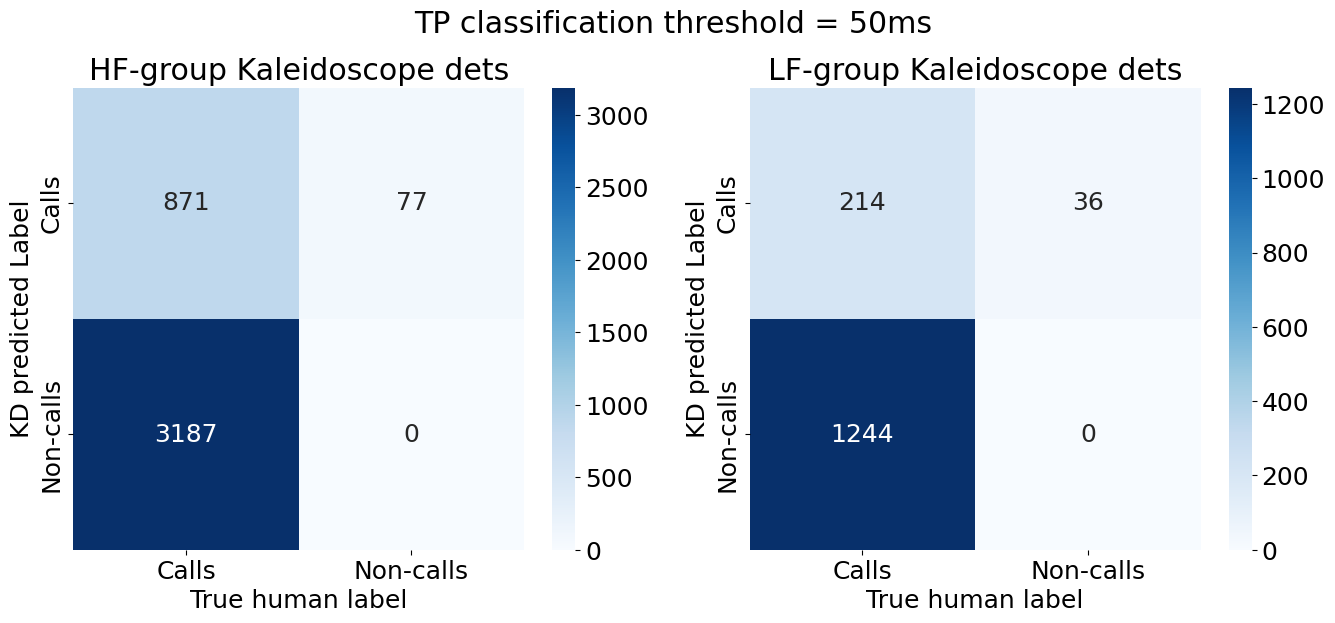

In [73]:
all_files_batdetct2_df = pd.DataFrame()
lf_files_batdetct2_df = pd.DataFrame()
hf_files_batdetct2_df = pd.DataFrame()

lf_files_human_df = pd.DataFrame()
hf_files_human_df = pd.DataFrame()

lf_files_true_positives_batdetct2_df = pd.DataFrame()
hf_files_true_positives_batdetct2_df = pd.DataFrame()
lf_files_true_positives_human_df = pd.DataFrame()
hf_files_true_positives_human_df = pd.DataFrame()

lf_files_false_positives_batdetct2_df = pd.DataFrame()
hf_files_false_positives_batdetct2_df = pd.DataFrame()

lf_files_false_negatives_batdetct2_df = pd.DataFrame()
hf_files_false_negatives_batdetct2_df = pd.DataFrame()

for file_key in file_keys:
    wav_filename = file_key
    site = FILE_SITES[file_key]
    plot_file = Path(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=RAVENPRO_TABLE_FORMAT)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)
    bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)

    kdpro_dets_filepath = (KALEIDOSCOPE_DETS_SAVE_DIR / f'{file_key}/output/neutral/cluster.csv')
    kdpro_dets = pd.read_csv(kdpro_dets_filepath)
    kdpro_dets_bd2_format = convert_kaleidoscopedf_to_bd2df(kdpro_dets)

    audio_file = sf.SoundFile(plot_file)
    fs = audio_file.samplerate
    nyquist = fs/2
    call_snrs = []
    peak_freqs_spec = []
    peak_freqs_welch =[]
    peak_freq_times_spec = []
    classes = []
    for i, row in kdpro_dets_bd2_format.iterrows():
        call_dur = (row['end_time'] - row['start_time'])
        audio_seg, length_of_section, pad = get_section_of_call_in_file(row, audio_file)
        seg_start = row['start_time'] - call_dur - (3*pad)

        audio_seg, length_of_section = batdetect2_pipeline.get_section_of_call_in_file(row, audio_file)

        freq_pad = 2000
        low_freq_cutoff = row['low_freq']-freq_pad
        high_freq_cutoff = min(nyquist-1, row['high_freq']+freq_pad)
        band_limited_audio_seg = batdetect2_pipeline.bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

        signal_for_peaks = band_limited_audio_seg.copy()
        signal_for_peaks[:int(fs*(length_of_section+pad))] = 0
        signal_for_peaks[-int(fs*pad):] = 0
        mpl_specgram_window = plt.mlab.window_hanning(np.ones(256))
        f, t, Sxx = scipy.signal.spectrogram(signal_for_peaks, fs, detrend=False,
                                    nfft=256, 
                                    window=mpl_specgram_window)
        plt_Sxx = 10*np.log10(Sxx)
        max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
        max_value_across_bins = Sxx[max_ind]
        peak_freq = f[max_ind[0]]
        peak_freq_time = t[max_ind[1]]
        tp_valid = ((seg_start+peak_freq_time[0]) >= row["start_time"])&((seg_start+peak_freq_time[0]) <= row["end_time"])
        if math.isinf(np.max(plt_Sxx)):
            peak_freqs_spec.append((row['low_freq']+row['high_freq'])/2)
            peak_freq_times_spec.append((row['start_time']+row['end_time'])/2)
        else:
            peak_freqs_spec.append(peak_freq[0])
            peak_freq_times_spec.append(seg_start+peak_freq_time[0])

        signal = band_limited_audio_seg.copy()
        signal[:int(fs*(length_of_section))] = 0
        noise = band_limited_audio_seg - signal
        snr_call_signal = signal[-int(fs*length_of_section):]
        snr_noise_signal = noise[:int(fs*length_of_section)]

        snr = batdetect2_pipeline.get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal)
        call_snrs.append(snr)

        welch_info = dict()
        welch_info['num_points'] = 100
        max_visible_frequency = 96000
        welch_info['max_freq_visible'] = max_visible_frequency
        welch_signal = batdetect2_pipeline.compute_welch_psd_of_call(snr_call_signal, fs, welch_info)

        peaks = np.where(welch_signal==max(welch_signal))[0][0]
        peak_freqs_welch.append(max_visible_frequency*(peaks/len(welch_signal)))
        
        welch_signal = (welch_signal).reshape(1, len(welch_signal))
        classes.append(LABEL_FOR_GROUPS[kmean_welch.predict(welch_signal)[0]])

    kdpro_dets_bd2_format['SNR'] = call_snrs
    kdpro_dets_bd2_format['peak_frequency_time_SPECTROGRAM'] = peak_freq_times_spec
    kdpro_dets_bd2_format['peak_frequency_SPECTROGRAM'] = peak_freqs_spec
    kdpro_dets_bd2_format['peak_frequency_WELCH'] = peak_freqs_welch
    kdpro_dets_bd2_format['freq_group'] = classes

    lf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].reset_index(drop=True).copy()
    hf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].reset_index(drop=True).copy()
    lf_kdpro_file_all_dets = kdpro_dets_bd2_format[kdpro_dets_bd2_format['freq_group']=='LF'].reset_index(drop=True).copy()
    hf_kdpro_file_all_dets = kdpro_dets_bd2_format[kdpro_dets_bd2_format['freq_group']=='HF'].reset_index(drop=True).copy()
    # print(f'KDPro detections: {len(kdpro_dets_bd2_format)} total, {len(lf_kdpro_file_all_dets)} LF, {len(hf_kdpro_file_all_dets)} HF')

    lf_association_matrix, lf_separated_performance_dfs = return_true_positives_using_human_df(lf_bd2_human_df_file, lf_kdpro_file_all_dets)
    hf_association_matrix, hf_separated_performance_dfs = return_true_positives_using_human_df(hf_bd2_human_df_file, hf_kdpro_file_all_dets)

    lf_human_true_positives = lf_separated_performance_dfs['human_true_positives']
    lf_bd2_false_negatives = lf_separated_performance_dfs['machine_false_negatives']
    lf_bd2_true_positives = lf_separated_performance_dfs['machine_true_positives']
    lf_bd2_false_positives = lf_separated_performance_dfs['machine_false_positives']
    lf_files_true_positives_batdetct2_df = pd.concat([lf_files_true_positives_batdetct2_df, lf_bd2_true_positives])
    lf_files_false_positives_batdetct2_df = pd.concat([lf_files_false_positives_batdetct2_df, lf_bd2_false_positives])
    lf_files_false_negatives_batdetct2_df = pd.concat([lf_files_false_negatives_batdetct2_df, lf_bd2_false_negatives])
    lf_files_true_positives_human_df = pd.concat([lf_files_true_positives_human_df, lf_human_true_positives])
    # print(f'LF measures: \n{len(lf_bd2_true_positives)} BD2 true positives\n{len(lf_bd2_false_negatives)} BD2 false negatives\n{len(lf_bd2_false_positives)} BD2 false positives\n{len(lf_human_true_positives)} human true positives')

    hf_human_true_positives = hf_separated_performance_dfs['human_true_positives']
    hf_bd2_false_negatives = hf_separated_performance_dfs['machine_false_negatives']
    hf_bd2_true_positives = hf_separated_performance_dfs['machine_true_positives']
    hf_bd2_false_positives = hf_separated_performance_dfs['machine_false_positives']
    hf_files_true_positives_batdetct2_df = pd.concat([hf_files_true_positives_batdetct2_df, hf_bd2_true_positives])
    hf_files_false_positives_batdetct2_df = pd.concat([hf_files_false_positives_batdetct2_df, hf_bd2_false_positives])
    hf_files_false_negatives_batdetct2_df = pd.concat([hf_files_false_negatives_batdetct2_df, hf_bd2_false_negatives])
    hf_files_true_positives_human_df = pd.concat([hf_files_true_positives_human_df, hf_human_true_positives])
    # print(f'HF measures: \n{len(hf_bd2_true_positives)} BD2 true positives\n{len(hf_bd2_false_negatives)} BD2 false negatives\n{len(hf_bd2_false_positives)} BD2 false positives\n{len(hf_human_true_positives)} human true positives')

lf_confusion_matrix = np.array([[len(lf_files_true_positives_batdetct2_df), len(lf_files_false_positives_batdetct2_df)],
                             [len(lf_files_false_negatives_batdetct2_df), 0]])
hf_confusion_matrix = np.array([[len(hf_files_true_positives_batdetct2_df), len(hf_files_false_positives_batdetct2_df)],
                             [len(hf_files_false_negatives_batdetct2_df), 0]])

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16, 6))
plt.rcParams.update({'font.size':18})
fig.suptitle(f'TP classification threshold = {int(1000*TP_CLASSIFICATION_THRESHOLD)}ms', y=1.01)
ax1.set_title(f'HF-group Kaleidoscope dets')
sns.heatmap(hf_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Calls', 'Non-calls'], 
                                                    yticklabels=['Calls', 'Non-calls'], ax=ax1)
ax1.set_xlabel('True human label')
ax1.set_ylabel('KD predicted Label')

ax2.set_title(f'LF-group Kaleidoscope dets')
sns.heatmap(lf_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Calls', 'Non-calls'], 
                                                    yticklabels=['Calls', 'Non-calls'], ax=ax2)
ax2.set_xlabel('True human label')
ax2.set_ylabel('KD predicted Label')

plt.show()